In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('Libraries loaded successfully')

Libraries loaded successfully


In [7]:
# Load the dataset
df = pd.read_csv("data/sleep_health_data.csv")

# --- 1. First 5 rows ---
print("=== First 5 Rows ===")
print(df.head())

# --- 2. Column data types ---
print("\n=== Column Data Types ===")
print(df.dtypes)

# --- 3. Missing / null values summary ---
print("\n=== Missing Value Summary ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
})
print(missing_summary[missing_summary["Missing Count"] > 0]
      .sort_values("Missing Count", ascending=False)
      .to_string() or "No missing values found.")

=== First 5 Rows ===
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125

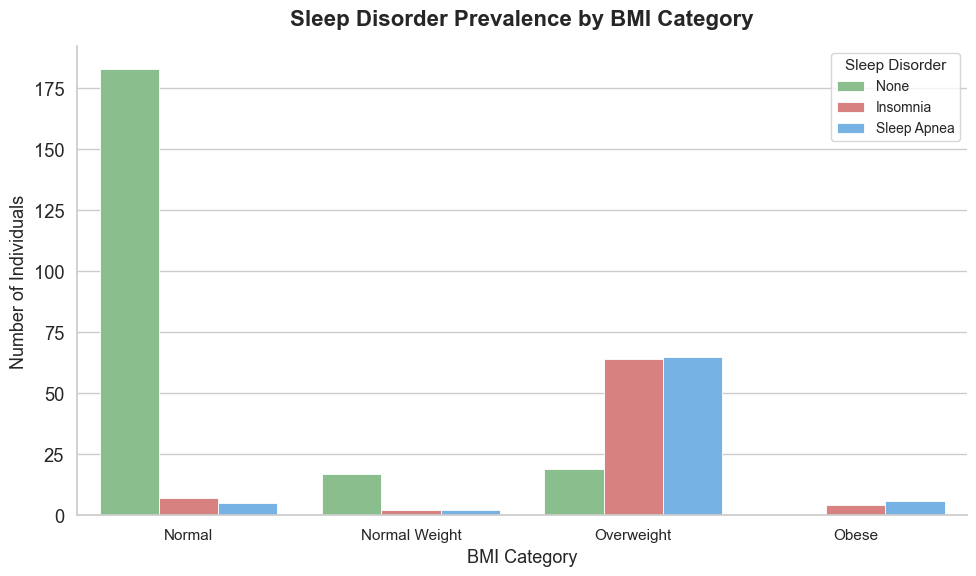

Saved → visualizations/bmi_vs_sleep_disorder.png


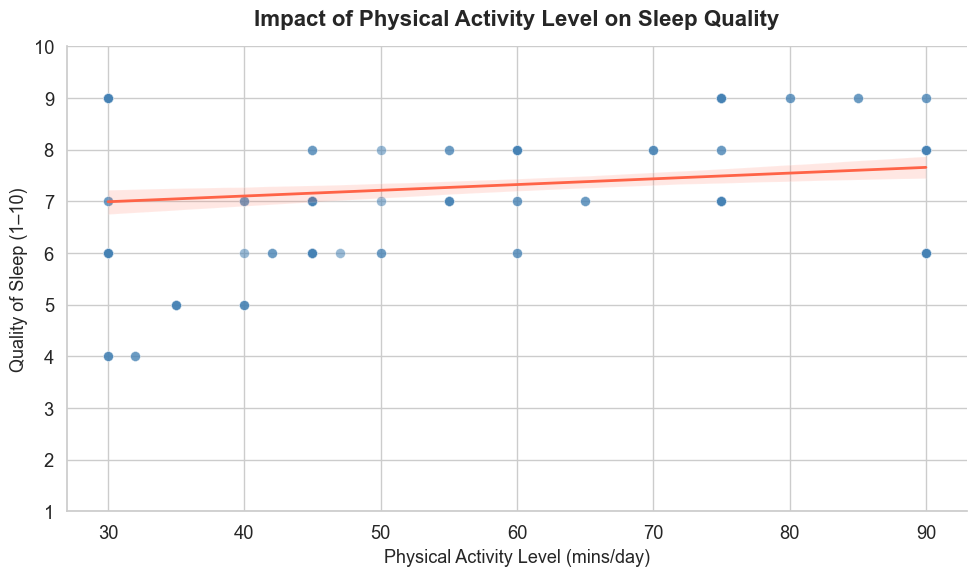

Saved → visualizations/activity_vs_sleep_quality.png


In [8]:
import os
os.makedirs("visualizations", exist_ok=True)

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

# ── Graph 1: BMI Category vs Sleep Disorder (Countplot) ──────────────────────
plot_df = df.copy()
plot_df["Sleep Disorder"] = plot_df["Sleep Disorder"].fillna("None")

bmi_order = ["Normal", "Normal Weight", "Overweight", "Obese"]
bmi_order = [b for b in bmi_order if b in plot_df["BMI Category"].unique()]
disorder_order = ["None", "Insomnia", "Sleep Apnea"]

fig1, ax1 = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=plot_df,
    x="BMI Category",
    hue="Sleep Disorder",
    order=bmi_order,
    hue_order=disorder_order,
    palette={"None": "#81c784", "Insomnia": "#e57373", "Sleep Apnea": "#64b5f6"},
    edgecolor="white",
    linewidth=0.6,
    ax=ax1
)

ax1.set_title("Sleep Disorder Prevalence by BMI Category", fontsize=16, fontweight="bold", pad=15)
ax1.set_xlabel("BMI Category", fontsize=13)
ax1.set_ylabel("Number of Individuals", fontsize=13)
ax1.legend(title="Sleep Disorder", title_fontsize=11, fontsize=10, loc="upper right")
ax1.tick_params(axis="x", labelsize=11)
sns.despine()

fig1.tight_layout()
fig1.savefig("visualizations/bmi_vs_sleep_disorder.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/bmi_vs_sleep_disorder.png")

# ── Graph 2: Physical Activity Level vs Quality of Sleep (Scatter + regression) ──
fig2, ax2 = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Physical Activity Level",
    y="Quality of Sleep",
    scatter_kws={"alpha": 0.55, "s": 50, "color": "steelblue", "edgecolors": "white", "linewidths": 0.4},
    line_kws={"color": "tomato", "linewidth": 2},
    ax=ax2
)

ax2.set_title("Impact of Physical Activity Level on Sleep Quality", fontsize=16, fontweight="bold", pad=15)
ax2.set_xlabel("Physical Activity Level (mins/day)", fontsize=13)
ax2.set_ylabel("Quality of Sleep (1–10)", fontsize=13)
ax2.set_yticks(range(1, 11))
sns.despine()

fig2.tight_layout()
fig2.savefig("visualizations/activity_vs_sleep_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/activity_vs_sleep_quality.png")

In [9]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ── 1. Prepare a clean copy ───────────────────────────────────────────────────
ml_df = df[['Age', 'Sleep Duration', 'Physical Activity Level',
            'BMI Category', 'Blood Pressure', 'Sleep Disorder']].copy()

# Fill NaN Sleep Disorder as 'None'
ml_df['Sleep Disorder'] = ml_df['Sleep Disorder'].fillna('None')

# ── 2. Encode Blood Pressure → systolic & diastolic ──────────────────────────
ml_df[['BP_Systolic', 'BP_Diastolic']] = (
    ml_df['Blood Pressure'].str.split('/', expand=True).astype(int)
)
ml_df.drop(columns=['Blood Pressure'], inplace=True)

# ── 3. Encode BMI Category (categorical string → integer) ────────────────────
bmi_encoder = LabelEncoder()
ml_df['BMI Category'] = bmi_encoder.fit_transform(ml_df['BMI Category'])
print("BMI Category encoding:", dict(zip(bmi_encoder.classes_,
                                          bmi_encoder.transform(bmi_encoder.classes_))))

# ── 4. Encode target: Sleep Disorder ─────────────────────────────────────────
target_encoder = LabelEncoder()
ml_df['Sleep Disorder'] = target_encoder.fit_transform(ml_df['Sleep Disorder'])
print("Sleep Disorder encoding:", dict(zip(target_encoder.classes_,
                                            target_encoder.transform(target_encoder.classes_))))

# ── 5. Features & target ──────────────────────────────────────────────────────
X = ml_df.drop(columns=['Sleep Disorder'])
y = ml_df['Sleep Disorder']

# ── 6. Train / test split (80 / 20) ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples: {len(X_train)} | Test samples: {len(X_test)}")

# ── 7. Train Random Forest (also compare Decision Tree) ──────────────────────
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# ── 8. Evaluate both models ───────────────────────────────────────────────────
for name, model in [("Decision Tree", dt_model), ("Random Forest", rf_model)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=target_encoder.classes_))


BMI Category encoding: {'Normal': np.int64(0), 'Normal Weight': np.int64(1), 'Obese': np.int64(2), 'Overweight': np.int64(3)}
Sleep Disorder encoding: {'Insomnia': np.int64(0), 'None': np.int64(1), 'Sleep Apnea': np.int64(2)}

Training samples: 299 | Test samples: 75

  Decision Tree
  Accuracy: 0.9600 (96.00%)
              precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75


  Random Forest
  Accuracy: 0.9600 (96.00%)
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96

## Business Logic / ROI Analysis

Using the predicted Sleep Apnea patients from the test set, we calculate the financial impact of deploying this predictive model.

| Scenario | Cost per Patient / Year |
|---|---|
| Untreated Sleep Apnea (ER costs) | $5,000 |
| Preventative Screening + CPAP Setup | $1,000 |

The **net savings** represents the ROI a hospital executive would achieve by acting on model predictions instead of waiting for emergency interventions.

In [10]:
def calculate_sleep_apnea_roi(
    n_predicted_apnea: int,
    cost_untreated: float = 5000.0,
    cost_intervention: float = 1000.0,
) -> dict:
    """
    Calculate the financial ROI of deploying a sleep apnea predictive model.

    Parameters
    ----------
    n_predicted_apnea  : Number of patients predicted to have Sleep Apnea.
    cost_untreated     : Annual ER cost per untreated patient  (default $5,000).
    cost_intervention  : Annual cost of screening + CPAP setup (default $1,000).

    Returns
    -------
    dict with total_financial_loss, total_intervention_cost, net_savings, roi_percent.
    """
    total_financial_loss    = n_predicted_apnea * cost_untreated
    total_intervention_cost = n_predicted_apnea * cost_intervention
    net_savings             = total_financial_loss - total_intervention_cost
    roi_percent             = (net_savings / total_intervention_cost) * 100

    return {
        "patients_identified":      n_predicted_apnea,
        "total_financial_loss":     total_financial_loss,
        "total_intervention_cost":  total_intervention_cost,
        "net_savings":              net_savings,
        "roi_percent":              roi_percent,
    }


# ── Pull predicted Sleep Apnea count from the Random Forest test results ──────
y_pred_rf    = rf_model.predict(X_test)
sleep_apnea_label = target_encoder.transform(["Sleep Apnea"])[0]   # encoded int for 'Sleep Apnea'
n_predicted_apnea = int((y_pred_rf == sleep_apnea_label).sum())

# ── Run the ROI calculation ───────────────────────────────────────────────────
roi = calculate_sleep_apnea_roi(n_predicted_apnea)

# ── Executive-facing report ───────────────────────────────────────────────────
print("=" * 55)
print("       SLEEP APNEA MODEL — EXECUTIVE ROI REPORT")
print("=" * 55)
print(f"  Patients Flagged by Model   : {roi['patients_identified']:>6}")
print(f"  Annual ER Cost (Untreated)  : ${roi['total_financial_loss']:>10,.0f}")
print(f"  Preventative Intervention   : ${roi['total_intervention_cost']:>10,.0f}")
print("-" * 55)
print(f"  NET SAVINGS (Annual)        : ${roi['net_savings']:>10,.0f}")
print(f"  ROI                         : {roi['roi_percent']:>9.1f}%")
print("=" * 55)
print(f"\n  By deploying this model, the health system avoids")
print(f"  ${roi['net_savings']:,.0f} in unnecessary ER spend per year —")
print(f"  a {roi['roi_percent']:.0f}% return on every dollar invested in")
print(f"  preventative care for flagged patients.")


       SLEEP APNEA MODEL — EXECUTIVE ROI REPORT
  Patients Flagged by Model   :     17
  Annual ER Cost (Untreated)  : $    85,000
  Preventative Intervention   : $    17,000
-------------------------------------------------------
  NET SAVINGS (Annual)        : $    68,000
  ROI                         :     400.0%

  By deploying this model, the health system avoids
  $68,000 in unnecessary ER spend per year —
  a 400% return on every dollar invested in
  preventative care for flagged patients.
